# 🤖 Aprendizagem de Máquina (AM)
## Notebook de Recuperação e Aprofundamento — Regressão e Clusterização

---

### 🏫 Informações institucionais

| Campo | Informação |
|---|---|
| **Escola** | E.E. Prof. João Cruz (EEJC) |
| **Rede** | Secretaria da Educação do Estado de São Paulo (SEDUC-SP) — Unidade Regional de Ensino de Jacareí (URE-Jacareí) |
| **Professor** | Heglas Oliveira |
| **E-mail institucional** | heglasoliveira@professor.educacao.sp.gov.br |
| **E-mail institucional (alternativo)** | heglasoliveira@prof.educacao.sp.gov.br |
| **Turma** | 3ª BT (Ensino Médio Técnico) |
| **Componente curricular** | Aprendizagem de Máquina (AM) |
| **Data** | 29/07/2026 (quarta-feira) |
| **Horários** | 07h50–08h40 (Aula 1) e 08h40–09h30 (Aula 2) |
| **Ação pedagógica** | Semana de Recuperação — Recuperação e Aprofundamento |

---

### ℹ️ Como usar este notebook

Este material foi construído para ser executado no **Google Colab** ou em **Jupyter Notebook**, utilizando apenas bibliotecas gratuitas e amplamente disponíveis: `numpy`, `pandas`, `matplotlib` e `scikit-learn`.

- Você não precisa instalar nada além do ambiente padrão do Colab.
- Não é necessário acesso à internet nem arquivos externos: todos os dados usados são **fictícios** e foram criados diretamente no notebook.
- Sempre que houver uma célula marcada com **✏️ Espaço para resposta/código**, é ali que você deve escrever sua solução.
- As células marcadas com **✅ Verificação automática** usam `assert` para conferir se sua resposta está correta. Se nada aparecer de erro ao rodar, está certo! Se aparecer um erro (`AssertionError`), revise seu raciocínio.
- As soluções do professor ficam **escondidas** em blocos recolhíveis (clique para abrir). Tente resolver sozinho(a) antes de conferir.
- Existe também uma **alternativa sem código** (ou com código parcialmente preenchido) para quem preferir registrar o raciocínio antes de programar, e uma **atividade de aprofundamento** para quem quiser ir além.

> 💡 **Dica:** no Google Colab, para executar uma célula, clique nela e pressione `Shift + Enter`.

---

### 🗺️ Agenda visual da aula (numerada)

1. **Abertura e diagnóstico inicial** — o que já sabemos sobre aprendizagem supervisionada e não supervisionada?
2. **Aula 1 (07h50–08h40) — Regressão:** dados, gráfico de dispersão, treino/teste, `LinearRegression`, reta ajustada, interpretação e métrica MAE.
3. **Aula 2 (08h40–09h30) — Clusterização:** dados sem rótulo, distância, `KMeans`, escolha de *k*, centróides e visualização dos grupos.
4. **Comparação final** entre regressão e clusterização.
5. **Desafio final integrador** + **atividade de aprofundamento**.
6. **Ticket de saída** e **rubrica formativa**.

---

### ♿ Acessibilidade deste material

- Instruções curtas, em blocos numerados e passo a passo.
- Glossário simples ao final de cada aula, com palavras-chave explicadas em linguagem direta.
- Alternativa **sem código** (responder com palavras ou preencher lacunas) em todos os exercícios principais.
- Códigos organizados em blocos pequenos, com comentários explicando cada linha.
- Atividade de aprofundamento separada, para quem quiser ir além do previsto na aula.

Este notebook não contém nomes, diagnósticos ou qualquer dado pessoal de estudantes.


In [1]:
# Configuração inicial do ambiente
# Importamos apenas bibliotecas gratuitas e padrão em Ciência de Dados

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.cluster import KMeans

# Ajustes visuais simples para os gráficos ficarem mais legíveis
plt.rcParams["figure.figsize"] = (6, 5)
plt.rcParams["font.size"] = 11

# Fixamos uma "semente" aleatória para que os resultados fictícios sejam sempre os mesmos
SEED = 42
np.random.seed(SEED)

print("Ambiente configurado com sucesso! Bibliotecas prontas para uso.")


Ambiente configurado com sucesso! Bibliotecas prontas para uso.


In [2]:
# Função auxiliar de verificação automática
# Ela avisa quando o exercício ainda não foi resolvido (valor None) e só valida quando houver uma resposta.

def verificar(condicao, mensagem_erro, ainda_nao_resolvido=False):
    # Confere uma condição booleana e imprime um retorno amigável.
    # Se 'ainda_nao_resolvido' for True, apenas avisa que falta completar o exercício (não interrompe a execução).
    if ainda_nao_resolvido:
        print("⏳ Exercício ainda não resolvido — substitua os valores 'None' pela sua resposta.")
        return
    assert condicao, mensagem_erro
    print("✅ Resposta correta! Muito bem.")

print("Função de verificação automática carregada.")


Função de verificação automática carregada.


## 🎯 Objetivos das duas aulas

Ao final destas duas aulas de 50 minutos, você será capaz de:

1. Diferenciar, com exemplos simples, **aprendizagem supervisionada** (regressão) de **aprendizagem não supervisionada** (clusterização).
2. **Aula 1 — Regressão:** construir um gráfico de dispersão, dividir dados em treino/teste, treinar um modelo `LinearRegression`, gerar previsões, visualizar a reta ajustada e interpretar coeficiente, intercepto e erro médio (MAE).
3. **Aula 2 — Clusterização:** organizar dados sem rótulo, escolher um valor inicial de *k*, treinar um modelo `KMeans`, identificar centróides e visualizar os agrupamentos formados.
4. Comparar regressão e clusterização quanto ao tipo de dado de entrada, ao objetivo do modelo e ao tipo de resultado produzido.

### 📋 Defasagens trabalhadas hoje (1ª Ficha de Diagnóstico — EEJC)

| Aula | Horário | Defasagem | Evidência esperada |
|---|---|---|---|
| Aula 1 | 07h50–08h40 | Introdução à regressão | Gráfico de dispersão com reta ajustada |
| Aula 2 | 08h40–09h30 | Introdução à clusterização | Agrupamento de dados não rotulados |

### 🔭 Por que isso importa agora

O **próximo plano quinzenal** (01 a 15/08/2026) avança para **KNN (K-Nearest Neighbors)** e **SVM (Support Vector Machine)** — dois algoritmos que dependem diretamente dos conceitos de hoje: **distância entre pontos**, **agrupamento por proximidade** e **ajuste de um modelo a partir de dados**. Consolidar regressão e clusterização agora facilita bastante o entendimento desses próximos algoritmos.


## 🔎 Diagnóstico inicial — Supervisionado x Não supervisionado (5 minutos)

Antes de começar, responda rapidamente — sem se preocupar em errar! Isso nos ajuda a saber de onde partir.

**Perguntas de sondagem** (responda mentalmente ou em voz alta na aula):

1. Você já ouviu falar em "aprendizagem supervisionada" e "aprendizagem não supervisionada"? O que você imagina que cada termo signifique?
2. Se eu te der uma tabela com o tamanho de várias casas e o preço de venda de cada uma, e eu quiser **prever o preço** de uma casa nova, que tipo de tarefa é essa?
3. Se eu te der uma lista de clientes de uma loja, **sem nenhum rótulo** (sem saber a categoria de cada um), e eu quiser **agrupar clientes parecidos**, que tipo de tarefa é essa?

### 🧭 Resumo rápido (sem "muita teoria")

| | Aprendizagem **supervisionada** | Aprendizagem **não supervisionada** |
|---|---|---|
| **Dados de entrada** | Têm um "gabarito" (rótulo/alvo) conhecido | **Não têm** rótulo conhecido |
| **Objetivo** | Aprender a **prever** o rótulo/valor de novos dados | Aprender a **agrupar/organizar** dados parecidos |
| **Exemplo de hoje** | Regressão: prever uma **nota** ou um **valor numérico** | Clusterização: agrupar estudantes ou itens **parecidos entre si** |
| **Algoritmo usado hoje** | `LinearRegression` | `KMeans` |


In [3]:
# Diagnóstico inicial rápido — registre suas respostas como texto (fictício, apenas para você mesmo)
# ✏️ Espaço para resposta/código

resposta_1 = "Escreva aqui o que você imagina que sejam aprendizagem supervisionada e não supervisionada..."
resposta_2 = "Escreva aqui: prever o preço de uma casa é supervisionada ou não supervisionada? Por quê?"
resposta_3 = "Escreva aqui: agrupar clientes sem rótulo é supervisionada ou não supervisionada? Por quê?"

print("Resposta 1:", resposta_1)
print("Resposta 2:", resposta_2)
print("Resposta 3:", resposta_3)


Resposta 1: Escreva aqui o que você imagina que sejam aprendizagem supervisionada e não supervisionada...
Resposta 2: Escreva aqui: prever o preço de uma casa é supervisionada ou não supervisionada? Por quê?
Resposta 3: Escreva aqui: agrupar clientes sem rótulo é supervisionada ou não supervisionada? Por quê?


---
# 🟦 AULA 1 — 07h50–08h40
# Introdução à Regressão

## Passo 1 — O que é regressão?

**Regressão** é uma técnica de aprendizagem **supervisionada** usada quando queremos **prever um valor numérico** a partir de uma ou mais variáveis de entrada.

- A variável de entrada é chamada de **X** (também chamada de "atributo" ou "variável independente").
- O valor que queremos prever é chamado de **y** (também chamado de "alvo", "rótulo" ou "variável dependente").

**Exemplo contextualizado (dados fictícios de escola):** vamos imaginar que registramos, para vários estudantes fictícios, o **número de horas de estudo por semana (X)** e a **nota final fictícia em uma prova (y)**. Queremos descobrir se existe uma relação entre essas duas variáveis e, se existir, usar essa relação para prever a nota de um novo estudante fictício.


In [4]:
# Passo 2 — Criando os dados fictícios (nenhum dado real de estudante é usado)
# X = horas de estudo por semana (variável de entrada)
# y = nota final fictícia (variável alvo), em escala de 0 a 10

np.random.seed(SEED)
horas_estudo = np.linspace(1, 10, 30)  # 30 estudantes fictícios, de 1 a 10 horas semanais
ruido = np.random.normal(loc=0, scale=0.6, size=horas_estudo.shape[0])  # pequena variação aleatória (realismo)
nota_final = 3.0 + 0.6 * horas_estudo + ruido  # relação aproximadamente linear, fictícia
nota_final = np.clip(nota_final, 0, 10)  # notas não podem passar de 10 nem ser negativas

dados_regressao = pd.DataFrame({
    "horas_estudo_semana": horas_estudo,
    "nota_final_ficticia": nota_final
})

dados_regressao.head()


,horas_estudo_semana,nota_final_ficticia
0,1.000000,3.898028
1,1.310345,3.703248
2,1.620690,4.361027
3,1.931034,5.072439
4,2.241379,4.204336


## Passo 3 — Gráfico de dispersão

Antes de treinar qualquer modelo, é fundamental **visualizar os dados**. Um **gráfico de dispersão** mostra cada estudante fictício como um ponto: a posição horizontal é o valor de X e a posição vertical é o valor de y.


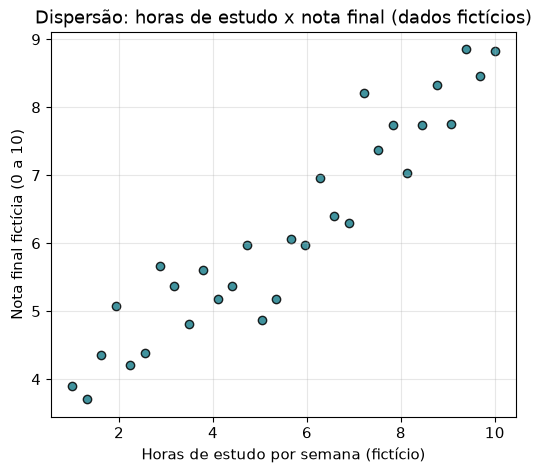

In [5]:
# Gráfico de dispersão: horas de estudo x nota final
plt.figure()
plt.scatter(dados_regressao["horas_estudo_semana"], dados_regressao["nota_final_ficticia"],
            color="#20808D", edgecolor="black", alpha=0.85)
plt.xlabel("Horas de estudo por semana (fictício)")
plt.ylabel("Nota final fictícia (0 a 10)")
plt.title("Dispersão: horas de estudo x nota final (dados fictícios)")
plt.grid(alpha=0.3)
plt.show()


## Passo 4 — Dividindo os dados em treino e teste

Para saber se o modelo aprendeu bem, **não podemos testá-lo com os mesmos dados usados no treino**. Por isso, separamos uma parte dos dados fictícios para **treino** (o modelo aprende com eles) e outra parte para **teste** (usamos para avaliar o modelo, como se fossem estudantes "novos").

Um valor comum é usar **80% para treino** e **20% para teste**.


In [6]:
# Passo 4 — Separando X (entrada) e y (alvo) e dividindo em treino/teste
X = dados_regressao[["horas_estudo_semana"]]  # X precisa ser uma tabela (2D) para o scikit-learn
y = dados_regressao["nota_final_ficticia"]     # y pode ser uma coluna (1D)

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print("Quantidade de estudantes fictícios no treino:", len(X_treino))
print("Quantidade de estudantes fictícios no teste:", len(X_teste))


Quantidade de estudantes fictícios no treino: 24
Quantidade de estudantes fictícios no teste: 6


## Passo 5 — Treinando o modelo `LinearRegression`

Agora vamos treinar o modelo de regressão linear **apenas com os dados de treino**. O modelo vai encontrar a **melhor reta** que descreve a relação entre horas de estudo e nota final.


In [7]:
# Passo 5 — Criando e treinando o modelo de regressão linear
modelo_regressao = LinearRegression()
modelo_regressao.fit(X_treino, y_treino)

print("Modelo treinado com sucesso!")
print("Coeficiente (inclinação da reta):", round(modelo_regressao.coef_[0], 3))
print("Intercepto (onde a reta cruza o eixo y):", round(modelo_regressao.intercept_, 3))


Modelo treinado com sucesso!
Coeficiente (inclinação da reta): 0.526
Intercepto (onde a reta cruza o eixo y): 3.287


## Passo 6 — Interpretando coeficiente e intercepto (de forma simples)

- **Coeficiente** (inclinação da reta): indica o quanto a nota final tende a **aumentar** para cada **1 hora adicional** de estudo por semana. Se o coeficiente for, por exemplo, `0.6`, isso significa que, em média, cada hora extra de estudo aumenta a nota em cerca de `0.6` ponto.
- **Intercepto**: é o valor previsto de nota final quando as horas de estudo são **zero**. É o ponto onde a reta "começa" no eixo vertical.

> ⚠️ **Atenção:** essa interpretação é uma simplificação didática — na prática, "zero horas de estudo" pode não fazer muito sentido real, mas o intercepto ajuda a entender matematicamente onde a reta começa.


## Passo 7 — Fazendo previsões e visualizando a reta ajustada


In [8]:
# Passo 7 — Prevendo notas para os dados de teste
previsoes_teste = modelo_regressao.predict(X_teste)

comparacao = pd.DataFrame({
    "horas_estudo_semana": X_teste["horas_estudo_semana"].values,
    "nota_real_ficticia": y_teste.values,
    "nota_prevista": np.round(previsoes_teste, 2)
})
comparacao


,horas_estudo_semana,nota_real_ficticia,nota_prevista
0,9.379310,8.853005,8.22
1,5.655172,6.055731,6.26
2,8.137931,7.027910,7.56
3,6.275862,6.954066,6.59
4,3.482759,4.807971,5.12
5,3.793103,5.601398,5.28


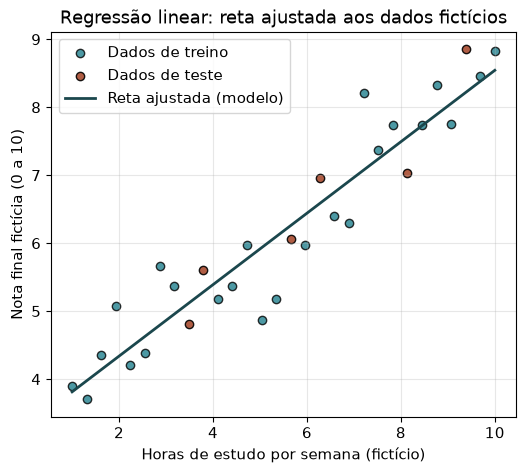

In [9]:
# Visualizando a reta ajustada sobre o gráfico de dispersão
plt.figure()
plt.scatter(X_treino, y_treino, color="#20808D", edgecolor="black", alpha=0.8, label="Dados de treino")
plt.scatter(X_teste, y_teste, color="#A84B2F", edgecolor="black", alpha=0.9, label="Dados de teste")

# Gerando a reta ajustada em toda a faixa de X para visualização
X_linha = np.linspace(X["horas_estudo_semana"].min(), X["horas_estudo_semana"].max(), 100).reshape(-1, 1)
y_linha = modelo_regressao.predict(pd.DataFrame(X_linha, columns=["horas_estudo_semana"]))

plt.plot(X_linha, y_linha, color="#1B474D", linewidth=2, label="Reta ajustada (modelo)")
plt.xlabel("Horas de estudo por semana (fictício)")
plt.ylabel("Nota final fictícia (0 a 10)")
plt.title("Regressão linear: reta ajustada aos dados fictícios")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Passo 8 — Avaliando o modelo com o MAE (Erro Médio Absoluto)

O **MAE** (*Mean Absolute Error*, ou Erro Médio Absoluto) mede, em média, **o quanto o modelo erra** ao prever cada valor — quanto **menor**, melhor. Como usamos a mesma escala da nota (0 a 10), um MAE de `0.5`, por exemplo, significa que o modelo erra, em média, meio ponto na nota.


In [10]:
# Passo 8 — Calculando o MAE nos dados de teste
mae = mean_absolute_error(y_teste, previsoes_teste)
print("MAE (Erro Médio Absoluto) nos dados de teste:", round(mae, 3))
print("Isso significa que, em média, o modelo erra cerca de", round(mae, 2), "ponto(s) na nota prevista.")


MAE (Erro Médio Absoluto) nos dados de teste: 0.396
Isso significa que, em média, o modelo erra cerca de 0.4 ponto(s) na nota prevista.


### 📖 Glossário simples — Aula 1 (Regressão)

| Termo | Explicação simples |
|---|---|
| **X (variável de entrada)** | O dado que usamos para fazer a previsão (ex.: horas de estudo). |
| **y (alvo)** | O valor que queremos prever (ex.: nota final). |
| **Treino** | Parte dos dados usada para o modelo "aprender". |
| **Teste** | Parte dos dados usada para "conferir" se o modelo aprendeu bem. |
| **Reta ajustada** | A reta que o modelo encontrou para representar a relação entre X e y. |
| **Coeficiente** | O quanto y muda para cada unidade que X aumenta. |
| **Intercepto** | O valor de y quando X é igual a zero. |
| **MAE** | Erro médio absoluto: quanto, em média, o modelo erra nas previsões. |


### ✏️ Exercício 1 — Lendo o gráfico de dispersão

Observando o gráfico de dispersão da Aula 1 (horas de estudo x nota final), responda completando o código abaixo:

1. À medida que as horas de estudo aumentam, a nota final tende a **aumentar** ou **diminuir**?
2. O coeficiente da reta ajustada é um número **positivo** ou **negativo**?

**Alternativa sem código:** se preferir, responda apenas com as palavras "aumentar"/"diminuir" e "positivo"/"negativo" em uma célula de texto, sem precisar rodar nada.


In [11]:
# ✏️ Espaço para resposta/código — Exercício 1
# Complete com "aumentar" ou "diminuir", e com "positivo" ou "negativo"

tendencia_nota = None      # substitua por "aumentar" ou "diminuir"
sinal_coeficiente = None   # substitua por "positivo" ou "negativo"

print("Tendência da nota:", tendencia_nota)
print("Sinal do coeficiente:", sinal_coeficiente)


Tendência da nota: None
Sinal do coeficiente: None


<details>
<summary>🔓 <b>Clique aqui para ver a solução do professor — Exercício 1</b></summary>

```python
tendencia_nota = "aumentar"     # conforme as horas de estudo aumentam, a nota também tende a aumentar
sinal_coeficiente = "positivo"  # o coeficiente calculado foi positivo (~0.6)

print("Tendência da nota:", tendencia_nota)
print("Sinal do coeficiente:", sinal_coeficiente)
```

**Explicação:** como os pontos do gráfico "sobem" da esquerda para a direita, e a reta ajustada também sobe, isso indica uma relação **positiva**: mais horas de estudo tendem a acompanhar notas mais altas nos dados fictícios.
</details>


In [12]:
# ✅ Verificação automática — Exercício 1
_pendente = tendencia_nota is None or sinal_coeficiente is None
verificar(tendencia_nota == "aumentar" and sinal_coeficiente == "positivo",
          "Reveja o gráfico: os pontos sobem da esquerda para a direita, e a reta também sobe.",
          ainda_nao_resolvido=_pendente)


⏳ Exercício ainda não resolvido — substitua os valores 'None' pela sua resposta.


### ✏️ Exercício 2 — Prevendo uma nota nova

Um novo estudante fictício estuda **7 horas por semana**. Use o modelo `modelo_regressao` já treinado para prever a nota final dele.

**Dica:** use `modelo_regressao.predict(...)`, passando uma tabela (`pd.DataFrame`) com uma coluna `horas_estudo_semana` igual a `[7]`.


In [13]:
# ✏️ Espaço para resposta/código — Exercício 2
novo_estudante = pd.DataFrame({"horas_estudo_semana": [7]})

nota_prevista_novo_estudante = None  # substitua None usando modelo_regressao.predict(novo_estudante)

print("Nota prevista para 7 horas de estudo semanais:", nota_prevista_novo_estudante)


Nota prevista para 7 horas de estudo semanais: None


<details>
<summary>🔓 <b>Clique aqui para ver a solução do professor — Exercício 2</b></summary>

```python
novo_estudante = pd.DataFrame({"horas_estudo_semana": [7]})
nota_prevista_novo_estudante = modelo_regressao.predict(novo_estudante)[0]

print("Nota prevista para 7 horas de estudo semanais:", round(nota_prevista_novo_estudante, 2))
```

**Explicação:** o modelo aplica a fórmula da reta ajustada (`coeficiente * X + intercepto`) ao novo valor de X = 7, retornando a nota prevista.
</details>


In [14]:
# ✅ Verificação automática — Exercício 2
_pendente = nota_prevista_novo_estudante is None
if not _pendente:
    _valor_previsto = float(np.ravel(nota_prevista_novo_estudante)[0])
    _esperado = float(modelo_regressao.predict(novo_estudante)[0])
    verificar(abs(_valor_previsto - _esperado) < 0.01,
              "Confira se você usou modelo_regressao.predict(novo_estudante).",
              ainda_nao_resolvido=False)
else:
    verificar(False, "", ainda_nao_resolvido=True)


⏳ Exercício ainda não resolvido — substitua os valores 'None' pela sua resposta.


---
---
# 🟩 AULA 2 — 08h40–09h30
# Introdução à Clusterização

## Passo 1 — O que é clusterização?

**Clusterização** é uma técnica de aprendizagem **não supervisionada**: os dados **não têm rótulo** (não sabemos, de antemão, a qual grupo cada ponto pertence). O objetivo do algoritmo é **descobrir grupos (clusters)** de itens parecidos entre si, observando a **distância** entre os pontos.

- Cada linha dos dados é descrita por **atributos** (características numéricas), sem nenhuma coluna de "resposta".
- Pontos que estão **próximos** (segundo alguma medida de distância) tendem a ficar no **mesmo grupo**.

**Exemplo contextualizado (dados fictícios de escola):** vamos imaginar que registramos, para vários estudantes fictícios, duas informações: o **tempo médio de estudo por dia (em minutos)** e a **quantidade de exercícios de fixação resolvidos por semana**. Não sabemos, a princípio, quais "perfis" de estudante existem — queremos que o algoritmo **descubra** esses perfis a partir dos dados.


In [15]:
# Passo 2 — Criando os dados fictícios sem rótulo (nenhum dado real de estudante é usado)
# Atributo 1: tempo médio de estudo por dia (minutos)
# Atributo 2: quantidade de exercícios resolvidos por semana

np.random.seed(SEED)

grupo_a = np.random.normal(loc=[20, 5], scale=[5, 2], size=(15, 2))   # perfil fictício "pouco estudo"
grupo_b = np.random.normal(loc=[60, 15], scale=[6, 3], size=(15, 2))  # perfil fictício "estudo moderado"
grupo_c = np.random.normal(loc=[100, 25], scale=[7, 3], size=(15, 2)) # perfil fictício "muito estudo"

atributos = np.vstack([grupo_a, grupo_b, grupo_c])
np.random.shuffle(atributos)  # embaralhamos para reforçar que os dados não têm rótulo

dados_cluster = pd.DataFrame(atributos, columns=["tempo_estudo_min_dia", "exercicios_semana"])
dados_cluster = dados_cluster.clip(lower=0)  # evita valores fictícios negativos

dados_cluster.head()


,tempo_estudo_min_dia,exercicios_semana
0,94.340545,23.494729
1,110.345258,23.445189
2,51.128868,12.840467
3,102.531452,23.064641
4,99.749218,29.693931


## Passo 3 — Visualizando os dados sem rótulo

Antes de aplicar qualquer algoritmo, observamos os dados em um gráfico de dispersão. Note que, diferente da Aula 1, aqui **não existe** uma coluna "y" — todos os pontos aparecem da mesma cor, porque ainda não sabemos os grupos.


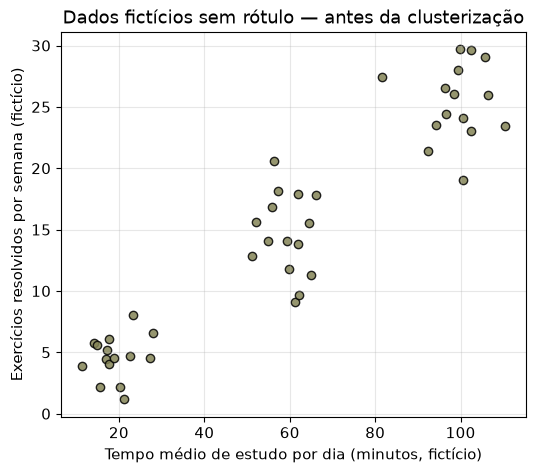

In [16]:
# Gráfico de dispersão dos dados sem rótulo
plt.figure()
plt.scatter(dados_cluster["tempo_estudo_min_dia"], dados_cluster["exercicios_semana"],
            color="#848456", edgecolor="black", alpha=0.85)
plt.xlabel("Tempo médio de estudo por dia (minutos, fictício)")
plt.ylabel("Exercícios resolvidos por semana (fictício)")
plt.title("Dados fictícios sem rótulo — antes da clusterização")
plt.grid(alpha=0.3)
plt.show()


## Passo 4 — Distância entre pontos

O `KMeans` usa a **distância** (geralmente a distância euclidiana, a "distância em linha reta") entre pontos para decidir quais estudantes fictícios são "parecidos" e devem ficar no mesmo grupo. Quanto **menor a distância**, mais parecidos os pontos são considerados.


In [17]:
# Exemplo simples de cálculo de distância euclidiana entre dois pontos fictícios
ponto_1 = np.array([20, 5])
ponto_2 = np.array([22, 6])
ponto_3 = np.array([100, 25])

distancia_1_2 = np.linalg.norm(ponto_1 - ponto_2)
distancia_1_3 = np.linalg.norm(ponto_1 - ponto_3)

print("Distância entre ponto_1 e ponto_2 (parecidos):", round(distancia_1_2, 2))
print("Distância entre ponto_1 e ponto_3 (bem diferentes):", round(distancia_1_3, 2))
print("Quanto menor a distância, mais parecidos os pontos são considerados pelo algoritmo.")


Distância entre ponto_1 e ponto_2 (parecidos): 2.24
Distância entre ponto_1 e ponto_3 (bem diferentes): 82.46
Quanto menor a distância, mais parecidos os pontos são considerados pelo algoritmo.


## Passo 5 — Escolhendo um valor inicial de *k*

No `KMeans`, precisamos informar **quantos grupos (k)** queremos encontrar. Observando o gráfico de dispersão da Aula 2, é possível notar visualmente **3 nuvens de pontos** — por isso, vamos começar com **k = 3** (essa é uma escolha introdutória; em turmas futuras, com KNN/SVM, vocês verão formas mais avançadas de escolher parâmetros como este).


In [18]:
# Passo 5 — Treinando o modelo KMeans com k = 3
# n_init=10 garante compatibilidade entre diferentes versões do scikit-learn
k_escolhido = 3
modelo_kmeans = KMeans(n_clusters=k_escolhido, random_state=SEED, n_init=10)
modelo_kmeans.fit(dados_cluster)

rotulos_grupos = modelo_kmeans.labels_
centroides = modelo_kmeans.cluster_centers_

print("Valor de k escolhido:", k_escolhido)
print("Rótulos de grupo atribuídos aos 10 primeiros pontos:", rotulos_grupos[:10])
print("Centróides encontrados (tempo de estudo, exercícios):")
print(np.round(centroides, 2))


Valor de k escolhido: 3
Rótulos de grupo atribuídos aos 10 primeiros pontos: [1 1 2 1 1 0 1 2 1 2]
Centróides encontrados (tempo de estudo, exercícios):
[[19.13  4.6 ]
 [99.18 25.43]
 [59.31 14.62]]


## Passo 6 — O que são centróides e rótulos de grupo?

- **Centróide**: é o "ponto médio" de cada grupo — representa o perfil típico daquele grupo (ex.: tempo de estudo médio e exercícios médios daquele agrupamento).
- **Rótulo de grupo**: é o número (0, 1, 2, ...) que o algoritmo atribuiu a cada ponto, indicando a qual grupo ele pertence. Esse rótulo **não existia antes** — ele foi **criado pelo algoritmo** a partir dos dados.


In [19]:
# Adicionando os rótulos de grupo encontrados à tabela de dados
dados_cluster_com_grupo = dados_cluster.copy()
dados_cluster_com_grupo["grupo"] = rotulos_grupos
dados_cluster_com_grupo.head(10)


,tempo_estudo_min_dia,exercicios_semana,grupo
0,94.340545,23.494729,1
1,110.345258,23.445189,1
2,51.128868,12.840467,2
3,102.531452,23.064641,1
4,99.749218,29.693931,1
5,27.896064,6.534869,0
6,106.407815,25.986253,1
7,56.389760,20.556835,2
8,100.642325,19.037293,1
9,64.935269,11.337469,2


## Passo 7 — Visualizando os agrupamentos formados


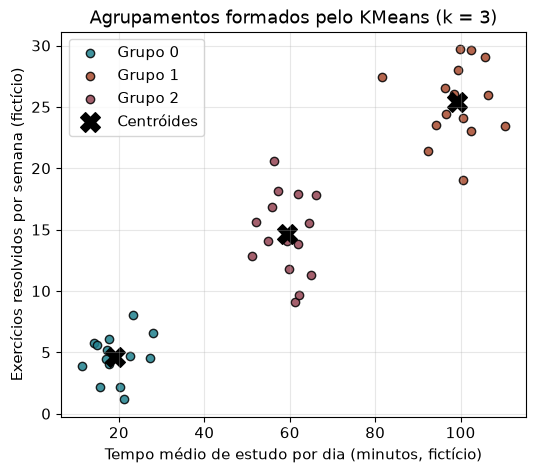

In [20]:
# Visualizando os grupos encontrados pelo KMeans, com os centróides em destaque
cores_grupos = ["#20808D", "#A84B2F", "#944454", "#FFC553", "#6E522B"]

plt.figure()
for grupo in range(k_escolhido):
    pontos_grupo = dados_cluster_com_grupo[dados_cluster_com_grupo["grupo"] == grupo]
    plt.scatter(pontos_grupo["tempo_estudo_min_dia"], pontos_grupo["exercicios_semana"],
                color=cores_grupos[grupo % len(cores_grupos)], edgecolor="black", alpha=0.85,
                label=f"Grupo {grupo}")

plt.scatter(centroides[:, 0], centroides[:, 1], color="black", marker="X", s=200,
            label="Centróides")

plt.xlabel("Tempo médio de estudo por dia (minutos, fictício)")
plt.ylabel("Exercícios resolvidos por semana (fictício)")
plt.title(f"Agrupamentos formados pelo KMeans (k = {k_escolhido})")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### 📖 Glossário simples — Aula 2 (Clusterização)

| Termo | Explicação simples |
|---|---|
| **Dados sem rótulo** | Dados em que não sabemos, de antemão, a qual grupo cada ponto pertence. |
| **Atributo** | Cada característica numérica usada para descrever um ponto (ex.: tempo de estudo). |
| **Distância** | Medida de quão "parecidos" ou "diferentes" dois pontos são. |
| **k** | Número de grupos que pedimos ao algoritmo para encontrar. |
| **Centróide** | O "ponto médio" que representa cada grupo encontrado. |
| **Rótulo de grupo** | O número do grupo atribuído pelo algoritmo a cada ponto. |


### ✏️ Exercício 3 — Contando estudantes fictícios por grupo

Complete o código abaixo para contar quantos estudantes fictícios ficaram em cada grupo formado pelo `KMeans`.

**Dica:** use `dados_cluster_com_grupo["grupo"].value_counts()`.

**Alternativa sem código:** observando o gráfico da Aula 2, escreva em uma célula de texto qual grupo (0, 1 ou 2) parece ter mais pontos.


In [21]:
# ✏️ Espaço para resposta/código — Exercício 3
contagem_por_grupo = None  # substitua usando dados_cluster_com_grupo["grupo"].value_counts()

print(contagem_por_grupo)


None


<details>
<summary>🔓 <b>Clique aqui para ver a solução do professor — Exercício 3</b></summary>

```python
contagem_por_grupo = dados_cluster_com_grupo["grupo"].value_counts()
print(contagem_por_grupo)
```

**Explicação:** o método `.value_counts()` conta quantas vezes cada valor (rótulo de grupo) aparece na coluna, mostrando quantos estudantes fictícios cada grupo reuniu.
</details>


In [22]:
# ✅ Verificação automática — Exercício 3
_pendente = contagem_por_grupo is None
if not _pendente:
    _esperado = dados_cluster_com_grupo["grupo"].value_counts()
    verificar(contagem_por_grupo.sort_index().equals(_esperado.sort_index()),
              "Confira se você usou dados_cluster_com_grupo['grupo'].value_counts().",
              ainda_nao_resolvido=False)
else:
    verificar(False, "", ainda_nao_resolvido=True)


⏳ Exercício ainda não resolvido — substitua os valores 'None' pela sua resposta.


### ✏️ Exercício 4 — Interpretando um centróide

Observe o centróide do **Grupo 0** (primeira linha de `centroides`). Complete o código abaixo para extrair o tempo médio de estudo e a quantidade média de exercícios desse grupo.

**Dica:** `centroides[0][0]` é o tempo de estudo do grupo 0; `centroides[0][1]` é a quantidade de exercícios do grupo 0.


In [23]:
# ✏️ Espaço para resposta/código — Exercício 4
tempo_estudo_grupo_0 = None      # substitua usando centroides[0][0]
exercicios_semana_grupo_0 = None # substitua usando centroides[0][1]

print("Tempo médio de estudo (Grupo 0):", tempo_estudo_grupo_0)
print("Exercícios médios por semana (Grupo 0):", exercicios_semana_grupo_0)


Tempo médio de estudo (Grupo 0): None
Exercícios médios por semana (Grupo 0): None


<details>
<summary>🔓 <b>Clique aqui para ver a solução do professor — Exercício 4</b></summary>

```python
tempo_estudo_grupo_0 = centroides[0][0]
exercicios_semana_grupo_0 = centroides[0][1]

print("Tempo médio de estudo (Grupo 0):", round(tempo_estudo_grupo_0, 2))
print("Exercícios médios por semana (Grupo 0):", round(exercicios_semana_grupo_0, 2))
```

**Explicação:** cada linha da matriz `centroides` representa um grupo, e cada coluna representa um atributo (na mesma ordem das colunas usadas no `KMeans`).
</details>


In [24]:
# ✅ Verificação automática — Exercício 4
_pendente = tempo_estudo_grupo_0 is None or exercicios_semana_grupo_0 is None
if not _pendente:
    verificar(abs(float(tempo_estudo_grupo_0) - float(centroides[0][0])) < 0.01 and
              abs(float(exercicios_semana_grupo_0) - float(centroides[0][1])) < 0.01,
              "Confira os índices usados em centroides[0][0] e centroides[0][1].",
              ainda_nao_resolvido=False)
else:
    verificar(False, "", ainda_nao_resolvido=True)


⏳ Exercício ainda não resolvido — substitua os valores 'None' pela sua resposta.


---
## ⚖️ Comparação final: Regressão x Clusterização

| Aspecto | Regressão (Aula 1) | Clusterização (Aula 2) |
|---|---|---|
| **Tipo de aprendizagem** | Supervisionada | Não supervisionada |
| **Dados de entrada** | X (entrada) e y (alvo/rótulo conhecido) | Apenas atributos, **sem rótulo** |
| **Objetivo do modelo** | Prever um **valor numérico** novo | Descobrir **grupos** de itens parecidos |
| **Algoritmo usado hoje** | `LinearRegression` | `KMeans` |
| **Resultado principal** | Reta ajustada + valor previsto | Centróides + rótulo de grupo |
| **Métrica usada hoje** | MAE (erro médio absoluto) | Distância entre pontos e centróides |
| **Exemplo de hoje** | Prever nota final a partir de horas de estudo | Agrupar estudantes fictícios por tempo de estudo e exercícios resolvidos |

> 🔗 **Conexão com o próximo conteúdo:** tanto o **KNN** quanto o **SVM** (próxima quinzena) utilizam a ideia de **distância entre pontos**, que vimos na clusterização, e a ideia de **ajustar um modelo a dados de treino**, que vimos na regressão. Por isso, dominar bem os conceitos de hoje ajuda muito nas próximas aulas.


---
## 🏆 Desafio final integrador

Neste desafio, vamos usar **os dois conceitos da aula** com um novo conjunto de dados fictícios de uma "trilha de estudos" de Ciência de Dados.

**Contexto fictício:** uma escola registrou, para vários estudantes fictícios, o **número de projetos práticos concluídos (X)** e a **nota final fictícia em um curso (y)**. Além disso, dispõe de dois atributos (**horas semanais dedicadas** e **número de dúvidas tiradas com o professor**) para tentar agrupar os estudantes fictícios em perfis de estudo.

**Sua tarefa:**
1. Treine uma regressão linear usando `projetos_concluidos` como X e `nota_curso` como y, e calcule o MAE nos dados de teste.
2. Treine um `KMeans` com k = 2 usando os atributos `horas_semanais` e `duvidas_tiradas`, e descubra quantos estudantes fictícios ficaram em cada grupo.


In [25]:
# Dados fictícios do desafio final integrador
np.random.seed(SEED)

projetos_concluidos = np.random.randint(1, 10, size=25)
nota_curso = np.clip(4 + 0.55 * projetos_concluidos + np.random.normal(0, 0.7, size=25), 0, 10)

horas_semanais = np.concatenate([
    np.random.normal(5, 1.5, size=13),
    np.random.normal(15, 2, size=12)
])
duvidas_tiradas = np.concatenate([
    np.random.normal(1, 0.5, size=13),
    np.random.normal(5, 1, size=12)
])
horas_semanais = np.clip(horas_semanais, 0, None)
duvidas_tiradas = np.clip(duvidas_tiradas, 0, None)

dados_desafio_regressao = pd.DataFrame({
    "projetos_concluidos": projetos_concluidos,
    "nota_curso": nota_curso
})

dados_desafio_cluster = pd.DataFrame({
    "horas_semanais": horas_semanais,
    "duvidas_tiradas": duvidas_tiradas
})

print("Dados do desafio criados. Linhas (regressão):", len(dados_desafio_regressao),
      "| Linhas (clusterização):", len(dados_desafio_cluster))


Dados do desafio criados. Linhas (regressão): 25 | Linhas (clusterização): 25


In [26]:
# ✏️ Espaço para resposta/código — Desafio final integrador

# PARTE 1 — Regressão
X_desafio = dados_desafio_regressao[["projetos_concluidos"]]
y_desafio = dados_desafio_regressao["nota_curso"]

X_treino_d, X_teste_d, y_treino_d, y_teste_d = train_test_split(
    X_desafio, y_desafio, test_size=0.2, random_state=SEED
)

modelo_desafio_regressao = None  # substitua criando e treinando um LinearRegression()
mae_desafio = None               # substitua calculando o MAE nos dados de teste

# PARTE 2 — Clusterização
modelo_desafio_kmeans = None  # substitua criando e treinando um KMeans(n_clusters=2, random_state=SEED, n_init=10)
contagem_grupos_desafio = None  # substitua contando quantos pontos ficaram em cada grupo

print("MAE do desafio (regressão):", mae_desafio)
print("Contagem por grupo (clusterização):")
print(contagem_grupos_desafio)


MAE do desafio (regressão): None
Contagem por grupo (clusterização):
None


<details>
<summary>🔓 <b>Clique aqui para ver a solução do professor — Desafio final integrador</b></summary>

```python
# PARTE 1 — Regressão
modelo_desafio_regressao = LinearRegression()
modelo_desafio_regressao.fit(X_treino_d, y_treino_d)
previsoes_desafio = modelo_desafio_regressao.predict(X_teste_d)
mae_desafio = mean_absolute_error(y_teste_d, previsoes_desafio)

# PARTE 2 — Clusterização
modelo_desafio_kmeans = KMeans(n_clusters=2, random_state=SEED, n_init=10)
modelo_desafio_kmeans.fit(dados_desafio_cluster)
contagem_grupos_desafio = pd.Series(modelo_desafio_kmeans.labels_).value_counts()

print("MAE do desafio (regressão):", round(mae_desafio, 3))
print("Contagem por grupo (clusterização):")
print(contagem_grupos_desafio)
```

**Explicação:** a lógica é a mesma das duas aulas — na regressão, treinamos com X/y e avaliamos com MAE; na clusterização, treinamos apenas com atributos (sem y) e observamos os rótulos de grupo criados pelo algoritmo.
</details>


In [27]:
# ✅ Verificação automática — Desafio final integrador
_pendente = (modelo_desafio_regressao is None or mae_desafio is None or
             modelo_desafio_kmeans is None or contagem_grupos_desafio is None)

if not _pendente:
    _previsoes_check = modelo_desafio_regressao.predict(X_teste_d)
    _mae_check = mean_absolute_error(y_teste_d, _previsoes_check)
    _labels_check = modelo_desafio_kmeans.labels_
    _contagem_check = pd.Series(_labels_check).value_counts().sort_index()

    verificar(
        abs(float(mae_desafio) - float(_mae_check)) < 0.5 and
        len(contagem_grupos_desafio) == 2 and
        contagem_grupos_desafio.sort_index().sum() == len(dados_desafio_cluster),
        "Confira se o modelo de regressão foi treinado com X_treino_d/y_treino_d e se o KMeans usou n_clusters=2.",
        ainda_nao_resolvido=False
    )
else:
    verificar(False, "", ainda_nao_resolvido=True)


⏳ Exercício ainda não resolvido — substitua os valores 'None' pela sua resposta.


---
## 🚀 Atividade de aprofundamento (para quem quiser ir além)

**Pergunta de investigação:** o que acontece se testarmos **outros valores de k** no KMeans do desafio final integrador (por exemplo, k = 3 ou k = 4), em vez de k = 2?

**Tarefa:**
1. Treine novos modelos `KMeans` com k = 3 e k = 4 nos mesmos dados (`dados_desafio_cluster`).
2. Compare visualmente os agrupamentos formados.
3. Em uma célula de texto, escreva sua conclusão: o agrupamento em k = 2 parece mais adequado que k = 3 ou k = 4? Por quê?

> 💡 Esse tipo de investigação (testar diferentes valores de k) é o primeiro passo para métodos mais avançados de escolha de parâmetros, que vocês vão aprofundar em breve com KNN e SVM.


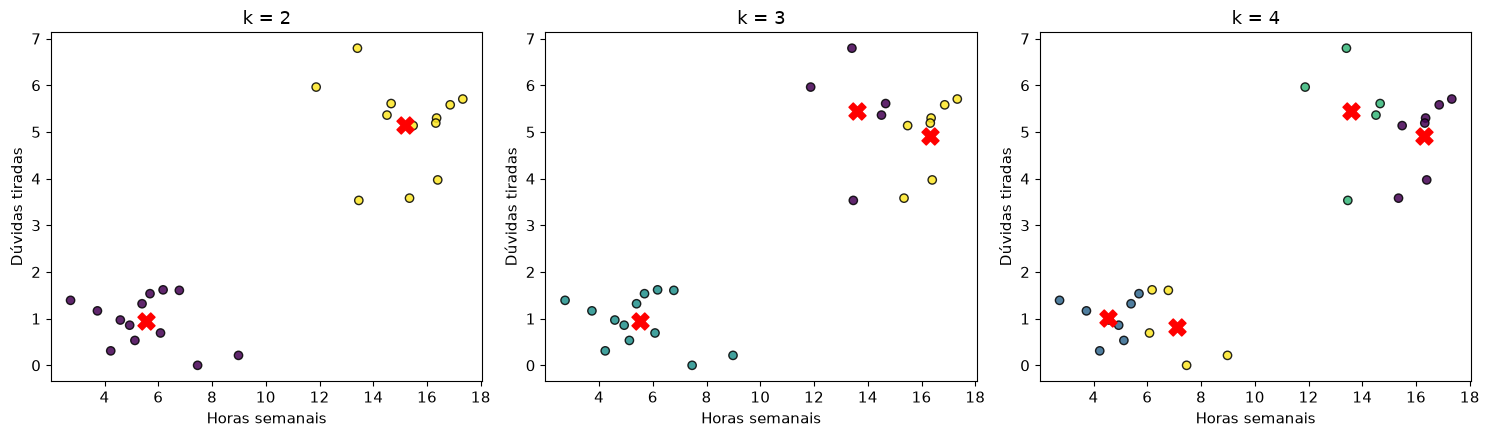

Escreva aqui sua conclusão sobre o valor de k mais adequado...


In [28]:
# ✏️ Espaço para resposta/código — Aprofundamento
k_valores_teste = [2, 3, 4]
modelos_aprofundamento = {}

for k in k_valores_teste:
    modelo_k = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    modelo_k.fit(dados_desafio_cluster)
    modelos_aprofundamento[k] = modelo_k

fig, eixos = plt.subplots(1, len(k_valores_teste), figsize=(15, 4.5))
for eixo, k in zip(eixos, k_valores_teste):
    modelo_k = modelos_aprofundamento[k]
    eixo.scatter(dados_desafio_cluster["horas_semanais"], dados_desafio_cluster["duvidas_tiradas"],
                 c=modelo_k.labels_, cmap="viridis", edgecolor="black", alpha=0.85)
    eixo.scatter(modelo_k.cluster_centers_[:, 0], modelo_k.cluster_centers_[:, 1],
                 color="red", marker="X", s=150)
    eixo.set_title(f"k = {k}")
    eixo.set_xlabel("Horas semanais")
    eixo.set_ylabel("Dúvidas tiradas")

plt.tight_layout()
plt.show()

# ✏️ Escreva sua conclusão sobre qual valor de k parece mais adequado, e por quê:
conclusao_aprofundamento = "Escreva aqui sua conclusão sobre o valor de k mais adequado..."
print(conclusao_aprofundamento)


<details>
<summary>🔓 <b>Clique aqui para ver a solução do professor — Aprofundamento</b></summary>

```python
# A criação dos modelos e o gráfico comparativo seguem o mesmo código do espaço de resposta.
# Conclusão esperada (exemplo):

conclusao_aprofundamento = (
    "Com k = 2 os grupos ficam bem separados e cada um representa um perfil claro "
    "(estudo mais leve x estudo mais intenso). Com k = 3 ou k = 4, o algoritmo passa a "
    "dividir esses mesmos dois perfis em subgrupos menores, que nem sempre fazem sentido "
    "prático — por isso, para este conjunto de dados fictícios, k = 2 parece mais adequado."
)
print(conclusao_aprofundamento)
```

**Explicação:** não existe um único valor "certo" de k — a escolha depende de quantos perfis realmente fazem sentido nos dados e no problema. Métodos mais formais de escolha de k (como o "método do cotovelo") serão vistos em aprofundamentos futuros.
</details>


In [29]:
# ✅ Verificação automática — Aprofundamento
_pendente = "Escreva aqui" in str(conclusao_aprofundamento)
verificar(len(str(conclusao_aprofundamento)) > 20,
          "Escreva uma conclusão com pelo menos algumas palavras sobre o valor de k mais adequado.",
          ainda_nao_resolvido=_pendente)


⏳ Exercício ainda não resolvido — substitua os valores 'None' pela sua resposta.


---
## 🎫 Ticket de saída

Antes de terminar a aula, responda rapidamente (pode ser em texto, sem código):

1. Em uma frase, explique a diferença entre **regressão** e **clusterização**.
2. Qual foi a parte mais fácil de entender hoje? E qual foi a mais difícil?
3. De 0 a 10, o quanto você se sente confiante para usar `LinearRegression` e `KMeans` em um notebook novo?


In [30]:
# ✏️ Espaço para resposta/código — Ticket de saída

diferenca_regressao_clusterizacao = "Escreva aqui sua explicação em uma frase..."
parte_mais_facil = "Escreva aqui..."
parte_mais_dificil = "Escreva aqui..."
nivel_confianca = None  # substitua por um número de 0 a 10

print("Diferença:", diferenca_regressao_clusterizacao)
print("Parte mais fácil:", parte_mais_facil)
print("Parte mais difícil:", parte_mais_dificil)
print("Nível de confiança (0 a 10):", nivel_confianca)


Diferença: Escreva aqui sua explicação em uma frase...
Parte mais fácil: Escreva aqui...
Parte mais difícil: Escreva aqui...
Nível de confiança (0 a 10): None


---
## 📊 Rubrica formativa simples

Use esta rubrica para autoavaliação ou para o professor registrar o encaminhamento de cada estudante.

| Critério | Iniciante | Em desenvolvimento | Consolidado |
|---|---|---|---|
| **Diferenciação supervisionado x não supervisionado** | Não distingue os dois tipos de aprendizagem. | Distingue com apoio de exemplos. | Distingue e exemplifica com autonomia. |
| **Regressão (gráfico e reta ajustada)** | Não constrói o gráfico de dispersão nem interpreta a reta. | Constrói o gráfico com apoio, mas tem dificuldade para interpretar a reta. | Constrói o gráfico, treina o modelo e interpreta coeficiente/intercepto com autonomia. |
| **Métrica MAE** | Não relaciona o MAE ao erro do modelo. | Calcula o MAE, mas tem dificuldade para interpretar o valor. | Calcula e interpreta o MAE com autonomia. |
| **Clusterização (KMeans)** | Não identifica atributos nem executa o KMeans. | Executa o KMeans com apoio, mas tem dificuldade para interpretar centróides/rótulos. | Executa o KMeans e interpreta centróides e rótulos de grupo com autonomia. |
| **Comparação final** | Não relaciona regressão e clusterização. | Relaciona com apoio de exemplos dados. | Compara e justifica as diferenças com autonomia. |

### Encaminhamento sugerido

- **Avanço satisfatório** (maioria "Consolidado"): propor a atividade de aprofundamento e desafios adicionais na próxima aula.
- **Avanço parcial** (mistura de "Em desenvolvimento" e "Consolidado"): retomar exemplo-modelo específico e oferecer nova questão de menor complexidade.
- **Fragilidade persistente** (maioria "Iniciante"): registrar a dificuldade específica (ex.: leitura do gráfico, cálculo de distância, interpretação do MAE) e planejar nova intervenção individualizada.

---

## ♿ Observação de acessibilidade (uso interno do professor)

Este notebook foi planejado considerando estudantes com Plano de Acessibilidade Curricular presentes na turma 3ª BT, por meio de:

- Agenda visual numerada no início do notebook.
- Instruções curtas e organizadas em blocos passo a passo.
- Glossário simples ao final de cada aula.
- Alternativas sem código (respostas em texto) em todos os exercícios principais.
- Código com comentários explicando cada etapa, para apoio de leitura.

Nenhum nome, diagnóstico ou dado pessoal de estudante da Educação Especial foi incluído neste material, em conformidade com a LGPD e as diretrizes internas da escola.

---

## 📝 Registro sugerido para o diário de classe

> Retomada das habilidades críticas de introdução à regressão e introdução à clusterização, identificadas na Ficha de Diagnóstico, por meio de explicação orientada, exercícios práticos com verificação automática, visualização gráfica (dispersão, reta ajustada e agrupamentos) e produção de evidências de aprendizagem (exercícios resolvidos, desafio final integrador, atividade de aprofundamento e ticket de saída).

---

## 📚 Referências e materiais de apoio (uso opcional)

- Documentação oficial do scikit-learn — Regressão Linear (gratuita): [scikit-learn.org/stable/modules/linear_model.html](https://scikit-learn.org/stable/modules/linear_model.html)
- Documentação oficial do scikit-learn — KMeans (gratuita): [scikit-learn.org/stable/modules/clustering.html#k-means](https://scikit-learn.org/stable/modules/clustering.html#k-means)
- Documentação oficial do NumPy (gratuita): [numpy.org/doc](https://numpy.org/doc/)
- Documentação oficial do Matplotlib (gratuita): [matplotlib.org](https://matplotlib.org/stable/index.html)
- Google Colab (ambiente gratuito para rodar este notebook): [colab.research.google.com](https://colab.research.google.com/)

---

**Professor:** Heglas Oliveira — E.E. Prof. João Cruz (EEJC) — SEDUC-SP
**E-mails institucionais:** heglasoliveira@professor.educacao.sp.gov.br · heglasoliveira@prof.educacao.sp.gov.br
**Data:** 29/07/2026 — 3ª BT — Aprendizagem de Máquina (AM) — Semana de Recuperação
